# Data normalisation
For this tank we need to normalise four datasets. This being the case, I will use a different form of normalisation for each dataset. To decide what method of normalisation I will be using, I will first guess based on the histogram of the data what could ne helpful (and eseier to implement).
> more info at https://github.com/lauradiosan/AI-UBB/blob/main/2025-2026/labs/lab02/dataNormalisation/AI-lab02-dataNormalisation.ipynb

### University study duration
From the code below, We can see thet our data fallows the Normal distribution. So we don't need `Clipping` and how we don't have BIG diffrences detween ower data (so no `Log sacling`) will do `Min-Max scaling`.

General usage if Min-Maxing:
+ You know the approximate upper and lower bounds on your data with few or no outliers
+ Your data is approximately uniformly distributed across that range

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

The point of this is to convert from a range (for as from (0, 8), but in most cases from (0, 1000)) to a range between (0, 1) or (-1, 1)

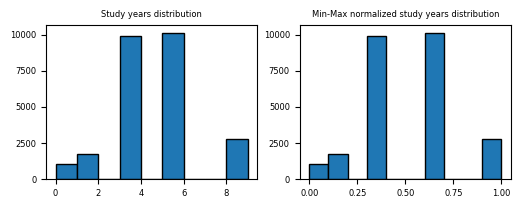

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def study_year(education: str):
    if education == 'No formal education past high school' or education == 'I prefer not to answer':
        return 0
    if education == "Some college/university study without earning a bachelor’s degree":
        return 1
    if education == "Bachelor’s degree":
        return 3
    if education == "Master’s degree":
        return 5
    if education == "Doctoral degree":
        return 8
    return None
    
df = pd.read_csv('data/surveyDataSience.csv', low_memory=False)
df["study_years"] = df["Q4"].apply(study_year)
plt.figure(figsize=(6,2))
plt.subplot(1, 2, 1)
plt.hist(df["study_years"].dropna(), bins=range(0, 10), edgecolor='black')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Study years distribution", fontsize=6)

min_years = min(df["study_years"].dropna())
max_years = max(df["study_years"].dropna())
new_df = [(x - min_years)/(max_years - min_years) for x in df["study_years"].dropna()]
plt.subplot(1, 2, 2)
plt.hist(new_df, bins=10, edgecolor='black')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Min-Max normalized study years distribution", fontsize=6)
plt.show()

### Coding age
In the fallowing example I'll do a `Log scale`. Even if at first thought I wanted to `Clip` the data thinking that the "20+ years" were outliers I no longer believe that thats the case: for one, there are a lot of them, and just because they are in the corner it dosne't mean they are outliers; if the scale were different (like a different Kernel function), the data would look more "normal".

General use of Log-Scaling:
+ Log scaling is helpful when a handful of your values have many points, while most other values have few points
$$
x' = log(x)
$$


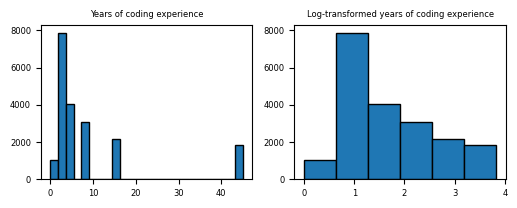

In [59]:
years_of_coding_avg_map = {
    "1-3 years": 2,
    "< 1 year": 0.5,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 45,
    "I have never written code": 0
}

df_oldness = df['Q6'].map(years_of_coding_avg_map)
plt.figure(figsize=(6,2))
plt.subplot(1, 2, 1)
plt.hist(df_oldness.dropna(), bins=25, edgecolor='black')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Years of coding experience", fontsize=6)

df_oldness_log = np.log(df_oldness.dropna() + 1)
plt.subplot(1, 2, 2)
plt.hist(df_oldness_log, bins=6, edgecolor='black')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Log-transformed years of coding experience", fontsize=6)
plt.show()

Also, for fun, the z-normalization formula is very similar to the formula for CLT, being more accurate in terms of how much we can transform the power set to follow the normal distribution. For this reason, I want to see if the data will follow a bell-like curve after normalization.

$$
z = \frac{x - \mu}{\sigma}
$$

Where:

- $x$ = original value  
- $\mu$ = mean of the dataset  
- $\sigma$ = standard deviation  
- $z$ = normalized value (z-score)

The CLT formula:
$$
\frac{\bar{X}_n - \mu}{\theta / \sqrt{n}} \sim N(0,1)
$$

Mean: 8.531977901652398, Std: 12.34540699708022
Min: -0.6911054373233928, Max: 2.9539748755932114


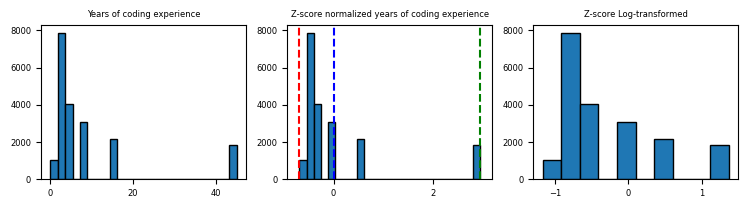

In [ ]:
mean_oldness = df_oldness.mean()
std_oldness = df_oldness.std()
print(f"Mean: {mean_oldness}, Std: {std_oldness}")

df_oldness_z_score = (df_oldness - mean_oldness) / std_oldness

print(f"Min: {df_oldness_z_score.min()}, Max: {df_oldness_z_score.max()}")

plt.figure(figsize=(9,2))
plt.subplot(1, 3, 1)
plt.hist(df_oldness, bins=25, edgecolor='black')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Years of coding experience", fontsize=6)

plt.subplot(1, 3, 2)
plt.hist(df_oldness_z_score.dropna(), bins=25, edgecolor='black')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Z-score normalized years of coding experience", fontsize=6)
plt.xlim(df_oldness_z_score.min() - 0.25, df_oldness_z_score.max() + 0.25)
plt.axvline(df_oldness_z_score.min(), color='red', linestyle='dashed', label='Min')
plt.axvline(df_oldness_z_score.max(), color='green', linestyle='dashed', label='Max')
plt.axvline(df_oldness_z_score.mean(), color='blue', linestyle='dashed', label='Mean')

df_oldness_z_scale_log = np.log(df_oldness_z_score.dropna() + 1)
plt.subplot(1, 3, 3)
plt.hist(df_oldness_z_scale_log, bins=10, edgecolor='black')
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Z-score Log-transformed", fontsize=6)
plt.show()


### Normalizing pixel values of images
I will do `Min-Max` because for imagines this is the most common type of normalization. Why? Welp this is what GoogleAI said:
+ **Faster Convergence:** It helps neural networks (especially CNNs) converge faster during training by keeping inputs in a smaller, consistent range.
+ **Numerical Stability:** It prevents large, raw pixel values (0–255) from causing gradient descent to struggle.

Oringinal min: 0.0, max: 255.0
Normalized min: 0.0, max: 1.0


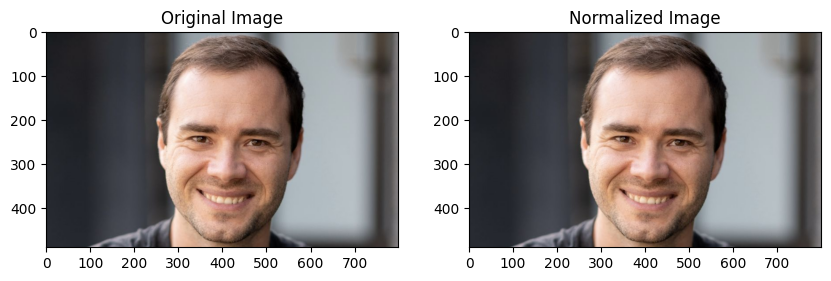

In [88]:
from PIL import Image

img = Image.open('images/Karpaty.jpg')
img_array = np.array(img).astype(np.float32)
print(f"Oringinal min: {img_array.min()}, max: {img_array.max()}")

img_norm = (img_array - img_array.min()) / (img_array.max() - img_array.min())
print(f"Normalized min: {img_norm.min()}, max: {img_norm.max()}")

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(img_norm)
plt.title("Normalized Image")
plt.show()

> spot the difference final boss

### The number of occurrences of words in a sentence.
Welp, we'll do for this `clipping`... because we haven't done any. :D <br>
Goal: Thresholding the data which caps all feature values above (or below) a certain value to fixed value. We use this if your data set contains extreme outliers.

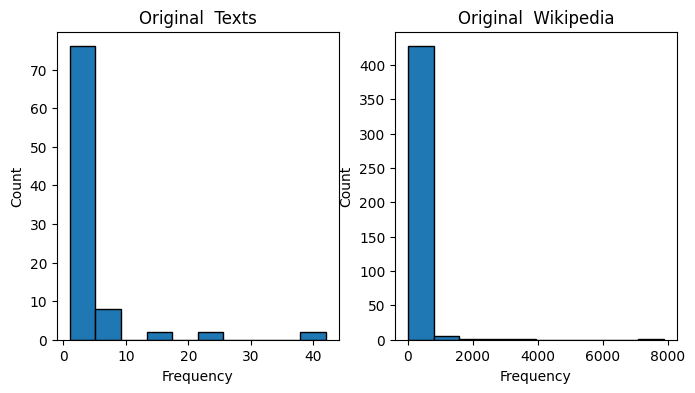

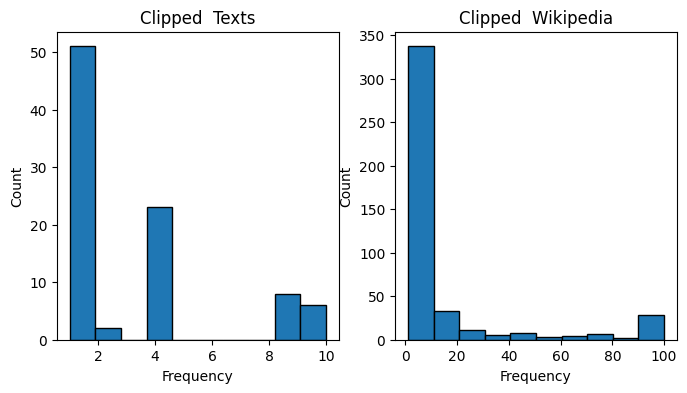

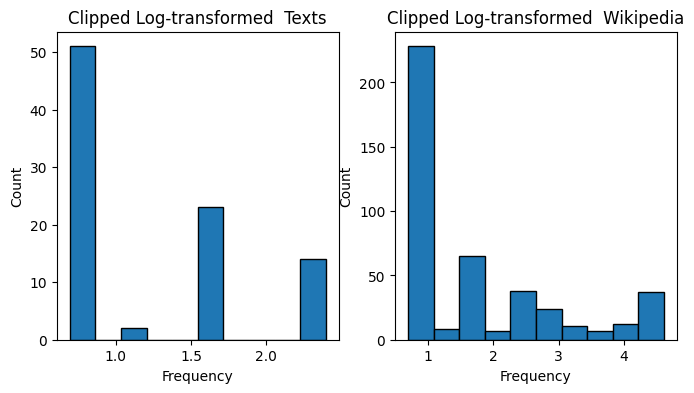

In [153]:
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

def word_frequency_distribution(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    words = word_tokenize(text)
    no_punctuation_words = [word for word in words if word.isalpha()]
    stremmed_words = [PorterStemmer().stem(word.lower()) for word in no_punctuation_words]
    lemmanized_words = [WordNetLemmatizer().lemmatize(word.lower()) for word in stremmed_words]

    word_count_per_sentence = {}
    for sentence in sent_tokenize(text):
        words_in_sentence = word_tokenize(sentence)
        no_punctuation_words_in_sentence = [word for word in words_in_sentence if word.isalpha()]
        stremmed_words_in_sentence = [PorterStemmer().stem(word.lower()) for word in no_punctuation_words_in_sentence]
        lemmanized_words_in_sentence = set([WordNetLemmatizer().lemmatize(word.lower()) for word in stremmed_words_in_sentence])
        
        for word in lemmanized_words:
            if word in lemmanized_words_in_sentence:
                word_count_per_sentence[word] = word_count_per_sentence.get(word, 0) + 1
      
    sorted_word_count = sorted(word_count_per_sentence.items(), key=lambda x: x[1], reverse=True)
    sorted_word_count

    return [count for _, count in sorted_word_count]

def plot_pear_wordfreq(dataset1, dataset2, text: str):
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.hist(dataset1, edgecolor='black')
    plt.title(text + " Texts")
    plt.xlabel("Frequency")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(dataset2, edgecolor='black')
    plt.title(text + " Wikipedia")
    plt.xlabel("Frequency")
    plt.ylabel("Count")
    plt.show()

words_freq_dist_1 = word_frequency_distribution("data/texts.txt")
words_freq_dist_2 = word_frequency_distribution("data/texts_wikipedia.txt")

plot_pear_wordfreq(words_freq_dist_1, words_freq_dist_2, text="Original ")

words_freq_dist_1_clipped = [count if count < 10 else 10 for count in words_freq_dist_1]
words_freq_dist_2_clipped = [count if count < 100 else 100 for count in words_freq_dist_2]

plot_pear_wordfreq(words_freq_dist_1_clipped, words_freq_dist_2_clipped, text="Clipped ")

words_freq_dist_1_clipped_log = np.log(np.array(words_freq_dist_1_clipped) + 1)
words_freq_dist_2_clipped_log = np.log(np.array(words_freq_dist_2_clipped) + 1)

plot_pear_wordfreq(words_freq_dist_1_clipped_log, words_freq_dist_2_clipped_log, text="Clipped Log-transformed ")
